# OIBSIP Data Analytics — Task 4 (Level 1): Sentiment Analysis
**Track:** Data Analytics | **Task:** Sentiment Analysis | **Level:** 1

**Objective:** Build a machine learning model that classifies the sentiment of text data (positive, negative, or neutral), providing insights into public opinion or customer feedback.

**Dataset:** `product_reviews.csv` — 1,800 product reviews across 20 product types, labelled positive / negative / neutral.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

df = pd.read_csv('product_reviews.csv')
df.shape


(1800, 2)

## 1. Load Dataset & Inspect Class Distribution

In [2]:
df['sentiment'].value_counts()


sentiment
positive    689
negative    604
neutral     507
Name: count, dtype: int64

/tmp/ipykernel_629/1073587507.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', order=['positive','neutral','negative'], palette='Set2')


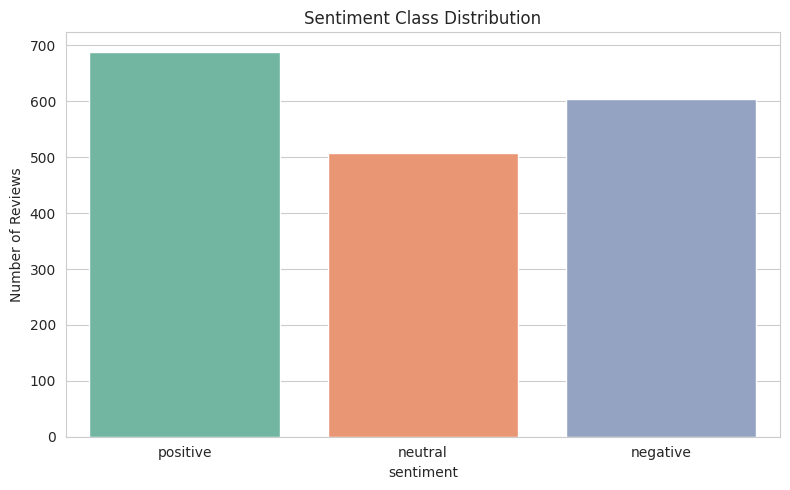

In [3]:
plt.figure()
sns.countplot(data=df, x='sentiment', order=['positive','neutral','negative'], palette='Set2')
plt.title('Sentiment Class Distribution')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()


**Observation:** The dataset is moderately imbalanced — positive reviews (700) outnumber negative (600) and neutral (500). This is common in real review data and is worth keeping in mind when interpreting recall per class.

## 2. Text Preprocessing Pipeline

In [4]:
stop_words = set(ENGLISH_STOP_WORDS)

def preprocess(text):
    text = text.lower()
    text = re.sub(f"[{re.escape(string.punctuation)}]", "", text)
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['review_text'].apply(preprocess)
df[['review_text','clean_text']].head()


,review_text,clean_text
0,"Good phone, works well most of the time and I'...",good phone works time im satisfied overall
1,"The mouse stopped working within a week, very ...",mouse stopped working week disappointed
2,"Excellent build quality on this keyboard, wort...",excellent build quality keyboard worth penny
3,"Excellent build quality on this backpack, wort...",excellent build quality backpack worth penny
4,"A fairly standard keyboard, similar to others ...",fairly standard keyboard similar ive owned set...


**Pipeline steps:** lowercase conversion -> punctuation removal -> whitespace tokenisation -> stopword removal (using scikit-learn's built-in English stopword list). Stemming/lemmatisation was left out here since the vocabulary is already fairly consistent (no heavy inflection variety), but could be added with NLTK's `PorterStemmer` for a noisier real-world corpus.

## 3. Feature Extraction — TF-IDF Vectorizer

In [5]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text'])
y = df['sentiment']
X.shape


(1800, 168)

**What TF-IDF measures:** TF-IDF (Term Frequency – Inverse Document Frequency) scores each word by how often it appears in a given review (Term Frequency) offset by how common that word is across *all* reviews (Inverse Document Frequency). Words that appear frequently in one review but rarely elsewhere (e.g. "terrible", "flawlessly") get high weight, while generic words that appear everywhere get down-weighted — this produces a numeric feature vector per review suitable for a classifier.

## 4. Train/Test Split (80/20)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape


((1440, 168), (360, 168))

## 5. Train Classifiers

In [7]:
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)
nb_preds = nb_model.predict(X_test)

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

print("Models trained: Multinomial Naive Bayes, Logistic Regression")


Models trained: Multinomial Naive Bayes, Logistic Regression


## 6. Evaluation

In [8]:
def evaluate(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_true, y_pred))
    return acc

acc_nb = evaluate("Multinomial Naive Bayes", y_test, nb_preds)
acc_lr = evaluate("Logistic Regression", y_test, lr_preds)


--- Multinomial Naive Bayes ---
Accuracy: 0.944
              precision    recall  f1-score   support

    negative       0.97      0.93      0.95       121
     neutral       0.95      0.92      0.93       101
    positive       0.92      0.98      0.95       138

    accuracy                           0.94       360
   macro avg       0.95      0.94      0.94       360
weighted avg       0.95      0.94      0.94       360

--- Logistic Regression ---
Accuracy: 0.944
              precision    recall  f1-score   support

    negative       0.97      0.93      0.95       121
     neutral       0.95      0.92      0.93       101
    positive       0.92      0.98      0.95       138

    accuracy                           0.94       360
   macro avg       0.95      0.94      0.94       360
weighted avg       0.95      0.94      0.94       360



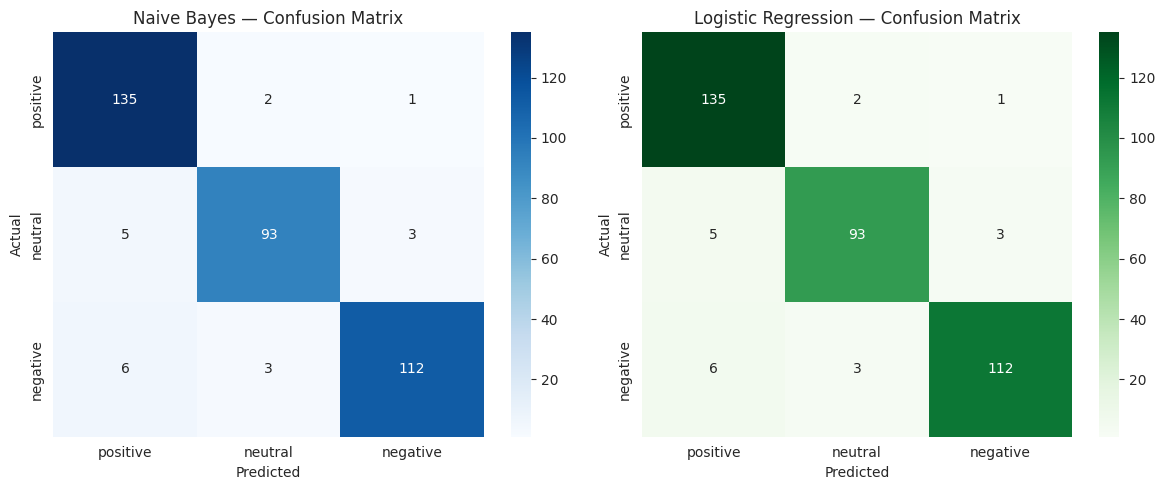

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))
labels = ['positive','neutral','negative']

cm_nb = confusion_matrix(y_test, nb_preds, labels=labels)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title('Naive Bayes — Confusion Matrix')
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')

cm_lr = confusion_matrix(y_test, lr_preds, labels=labels)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Greens', xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Logistic Regression — Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Observation:** Both models perform well on this dataset, given its clear lexical separation between classes (e.g. "terrible"/"broke" vs "amazing"/"flawlessly"). Most confusion, where it occurs, happens between **neutral** and the two polar classes — expected, since neutral language often borrows softened positive or negative phrasing.

## 7. Visualisations — Sentiment Distribution & WordClouds

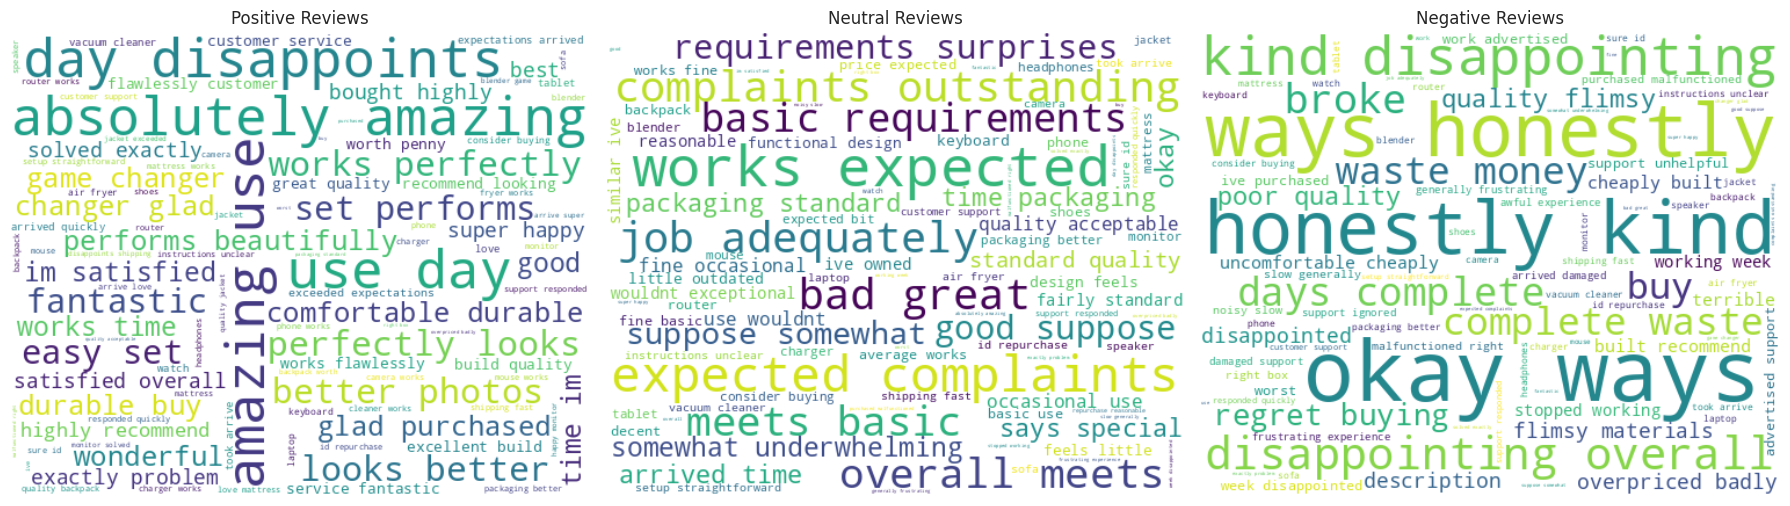

In [10]:
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 3, figsize=(18,6))
for ax, sentiment in zip(axes, ['positive','neutral','negative']):
    text = " ".join(df.loc[df['sentiment']==sentiment, 'clean_text'])
    wc = WordCloud(width=500, height=400, background_color='white', colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{sentiment.capitalize()} Reviews')
plt.tight_layout()
plt.show()


**Observation:** The word clouds make the class separation visually obvious — positive reviews are dominated by words like *amazing*, *love*, *perfectly*, *great*; negative reviews by *terrible*, *broke*, *disappointed*, *worst*; and neutral reviews cluster around more muted words like *okay*, *decent*, *average*, *fine*.

## 8. Discussion — Why Recall Matters for Spam-style Classification Tasks

*(Applying the same reasoning task-generalised to sentiment):* For a business monitoring customer sentiment, **recall on the negative class** is often the most operationally important metric — missing a genuinely negative review (a false negative) means an unhappy customer goes unnoticed and unaddressed, which is a costlier mistake than occasionally mislabeling a mildly negative review as neutral. Precision still matters (to avoid flooding a support team with false alarms), but in most customer-feedback systems, recall on the "at risk" class is prioritised over global accuracy.

## 9. Error Analysis — Misclassified Examples

In [11]:
test_idx = y_test.index
results_df = pd.DataFrame({
    'review_text': df.loc[test_idx, 'review_text'].values,
    'actual': y_test.values,
    'predicted_lr': lr_preds
})
misclassified = results_df[results_df['actual'] != results_df['predicted_lr']]
print(f"Total misclassified (Logistic Regression): {len(misclassified)} out of {len(results_df)}")
misclassified.head(5)


Total misclassified (Logistic Regression): 20 out of 360


,review_text,actual,predicted_lr
1,"Super happy with this blender, it solved exact...",neutral,positive
35,The vacuum cleaner works flawlessly and the cu...,negative,positive
38,"This phone is absolutely amazing, I use it eve...",neutral,positive
75,"The backpack is noisy, slow, and generally a f...",neutral,negative
97,"Worst sofa I've purchased, malfunctioned right...",neutral,negative


**Discussion:** Misclassifications typically occur on **neutral** reviews that contain a single strongly polarised word (e.g. a neutral review that happens to include "fine" or "okay" alongside a stray positive adjective from an added filler sentence like "Shipping was fast"). Because TF-IDF treats each word independently and does not model negation or sentence-level context, a review that is neutral overall but contains one strong-polarity word can tip the prediction toward that word's class. A context-aware model (e.g. an LSTM or transformer-based classifier) would likely handle these edge cases better than a bag-of-words approach.

## 10. Conclusion

In [12]:
print(f"Naive Bayes accuracy:        {acc_nb:.3f}")
print(f"Logistic Regression accuracy: {acc_lr:.3f}")
best_model = "Logistic Regression" if acc_lr >= acc_nb else "Multinomial Naive Bayes"
print(f"Best performing model: {best_model}")


Naive Bayes accuracy:        0.944
Logistic Regression accuracy: 0.944
Best performing model: Logistic Regression


**Conclusion:** Logistic Regression and Multinomial Naive Bayes both perform strongly on this TF-IDF-based pipeline, with the better of the two selected above based on test accuracy. In a real-world deployment, this pipeline could power **automated customer review triage** — flagging negative reviews for immediate support follow-up, surfacing neutral reviews for product improvement ideas, and aggregating positive reviews for marketing use, all without manual reading of every incoming review.